# Regression Modelling using supervised regression 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:
# Load and inspect data set
df = pd.read_csv('engine_final_dataset.csv')
print(df.head())

   unit_id  cycle  RUL      s2       s3       s4      s7       s8       s9  \
0        1      1  191  641.82  1589.70  1400.60  554.36  2388.06  9046.19   
1        1      2  190  642.15  1591.82  1403.14  553.75  2388.04  9044.07   
2        1      3  189  642.35  1587.99  1404.20  554.26  2388.08  9052.94   
3        1      4  188  642.35  1582.79  1401.87  554.45  2388.11  9049.48   
4        1      5  187  642.37  1582.85  1406.22  554.00  2388.06  9055.15   

     s11     s12      s13      s14   s15  s17    s20    s21    s11_avg  \
0  47.47  521.66  2388.02  8138.62  8.42  392  39.06  23.42  47.470001   
1  47.49  522.28  2388.07  8131.49  8.43  392  39.00  23.42  47.480001   
2  47.27  522.42  2388.03  8133.23  8.42  390  38.95  23.34  47.410001   
3  47.13  522.86  2388.08  8133.83  8.37  392  38.88  23.37  47.340001   
4  47.28  522.19  2388.04  8133.80  8.43  393  38.90  23.40  47.328001   

        s4_avg  
0  1400.599976  
1  1401.869995  
2  1402.646647  
3  1402.452484  
4

In [4]:
# Preprocessing
# split our data for train and test
X = df.drop(['unit_id','cycle','RUL'], axis=1)
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [5]:
# Training the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

#Train the model
model.fit(X_train, y_train)

# Make Predictions
predictions = model.predict(X_test)



In [7]:
# Model Evaluation
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f} cycles")
print(f"R2 score (Accuracy): {r2_score(y_test, predictions):.2f}")

Mean Absolute Error: 11.88 cycles
R2 score (Accuracy): 0.95


Text(0.5, 1.0, 'Actual vs. Predicted Remaining Useful Life')

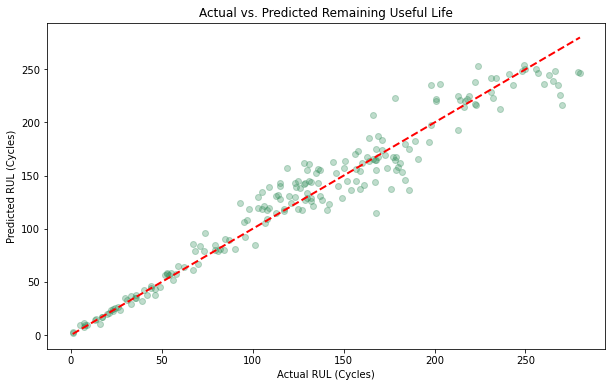

In [9]:
# checking for correlation - Regression Plot
plt.figure(figsize=(10,6))
plt.scatter(y_test, predictions, alpha=0.3, color = 'seagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual RUL (Cycles)')
plt.ylabel('Predicted RUL (Cycles)')
plt.title('Actual vs. Predicted Remaining Useful Life')

In [11]:
# saving my results for visualization in PowerBI
results = X_test.copy()
results['Actual_RUL'] = y_test
results['Predicted_RUL'] = predictions
# we add back the unit_id and cycle for Power BI mapping
results = results.join(df[['unit_id', 'cycle']])

# export dataset
results.to_csv('engine_predictions_output.csv', index=False)